In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [5]:
print(os.path.exists(r"C:\Users\tejas\OneDrive\Desktop\DRG_project\data\processed\neighbourhood_demand.csv"))

True


In [8]:
df = pd.read_csv(r"C:\Users\tejas\OneDrive\Desktop\DRG_project\data\processed\neighbourhood_demand.csv")

In [9]:
df["datetime"] = pd.to_datetime(df["datetime"])

df.head()

,datetime,total_demand_kwh
0,2011-11-23 10:00:00,0.150
1,2011-11-23 10:30:00,0.070
2,2011-11-23 11:00:00,0.033
3,2011-11-23 11:30:00,0.183
4,2011-11-23 12:00:00,0.315


In [10]:
df["hour"] = df["datetime"].dt.hour

df["day_name"] = df["datetime"].dt.day_name()

df["month"] = df["datetime"].dt.month

df["month_name"] = df["datetime"].dt.month_name()

df["weekday"] = df["datetime"].dt.weekday

df["is_weekend"] = df["weekday"].isin([5,6])

In [11]:
df.head()

,datetime,total_demand_kwh,hour,day_name,month,month_name,weekday,is_weekend
0,2011-11-23 10:00:00,0.150,10,Wednesday,11,November,2,False
1,2011-11-23 10:30:00,0.070,10,Wednesday,11,November,2,False
2,2011-11-23 11:00:00,0.033,11,Wednesday,11,November,2,False
3,2011-11-23 11:30:00,0.183,11,Wednesday,11,November,2,False
4,2011-11-23 12:00:00,0.315,12,Wednesday,11,November,2,False


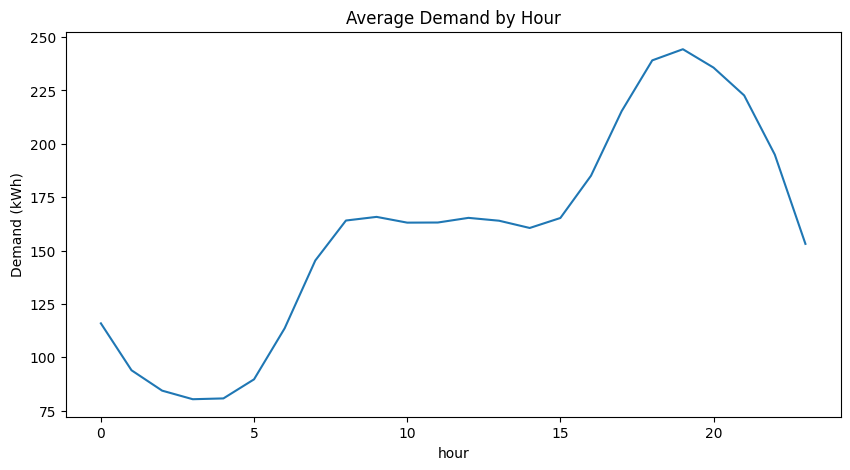

In [12]:
hourly = (
    df.groupby("hour")["total_demand_kwh"]
      .mean()
)

plt.figure(figsize=(10,5))

hourly.plot()

plt.title("Average Demand by Hour")

plt.ylabel("Demand (kWh)")

plt.show()

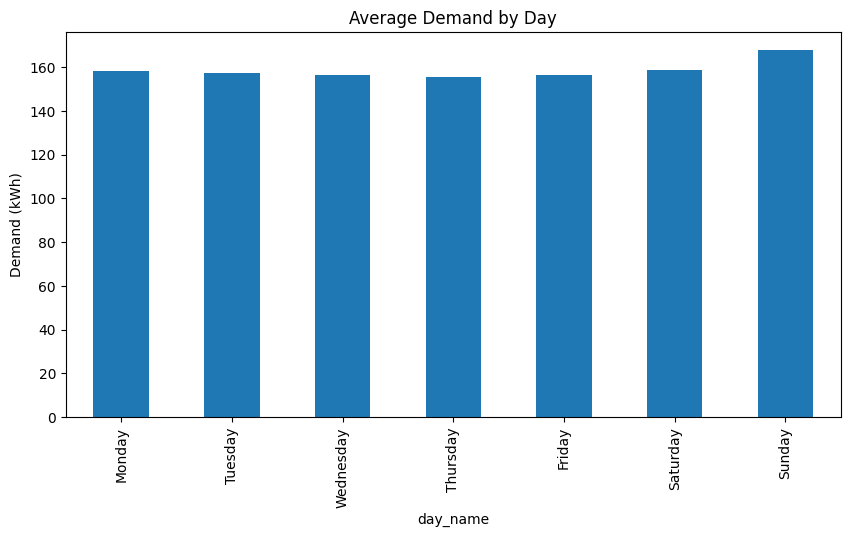

In [13]:
daily = (
    df.groupby("day_name")["total_demand_kwh"]
      .mean()
)

daily = daily.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(10,5))

daily.plot(kind="bar")

plt.title("Average Demand by Day")

plt.ylabel("Demand (kWh)")

plt.show()

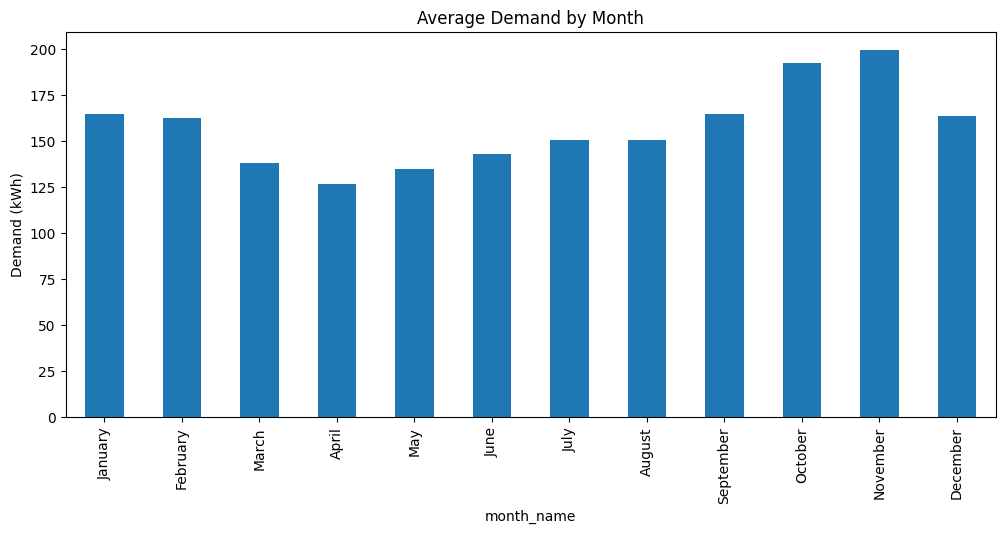

In [14]:
monthly = (
    df.groupby("month_name")["total_demand_kwh"]
      .mean()
)

monthly = monthly.reindex([
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
])

plt.figure(figsize=(12,5))

monthly.plot(kind="bar")

plt.title("Average Demand by Month")

plt.ylabel("Demand (kWh)")

plt.show()

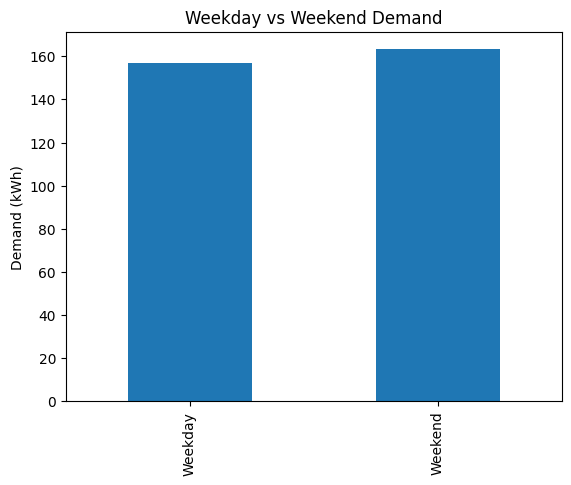

In [15]:
weekend = (
    df.groupby("is_weekend")["total_demand_kwh"]
      .mean()
)

weekend.index = [
    "Weekday",
    "Weekend"
]

weekend.plot(kind="bar")

plt.title("Weekday vs Weekend Demand")

plt.ylabel("Demand (kWh)")

plt.show()

In [16]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

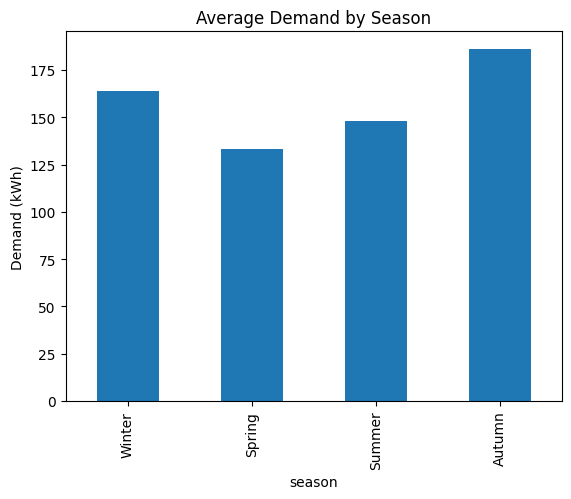

In [17]:
seasonal = (
    df.groupby("season")["total_demand_kwh"]
      .mean()
)

seasonal = seasonal.reindex([
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
])

seasonal.plot(kind="bar")

plt.title("Average Demand by Season")

plt.ylabel("Demand (kWh)")

plt.show()

In [18]:
peak_row = df.loc[
    df["total_demand_kwh"].idxmax()
]

peak_row

datetime            2013-01-18 19:00:00
total_demand_kwh                464.916
hour                                 19
day_name                         Friday
month                                 1
month_name                      January
weekday                               4
is_weekend                        False
season                           Winter
Name: 20274, dtype: object

In [27]:
import pandas as pd

# Load the file into the 'neighbourhood' variable
neighbourhood = pd.read_csv(r"C:\Users\tejas\OneDrive\Desktop\DRG_project\data\processed\neighbourhood_demand.csv")

# Now you can view the first 5 rows
neighbourhood.head()


,datetime,total_demand_kwh
0,2011-11-23 10:00:00,0.150
1,2011-11-23 10:30:00,0.070
2,2011-11-23 11:00:00,0.033
3,2011-11-23 11:30:00,0.183
4,2011-11-23 12:00:00,0.315


In [28]:
print(neighbourhood.describe())

       total_demand_kwh
count      39725.000000
mean         158.586525
std           97.449454
min            0.033000
25%           92.175000
50%          154.243000
75%          222.483000
max          464.916000


In [29]:
print(neighbourhood.head())


              datetime  total_demand_kwh
0  2011-11-23 10:00:00             0.150
1  2011-11-23 10:30:00             0.070
2  2011-11-23 11:00:00             0.033
3  2011-11-23 11:30:00             0.183
4  2011-11-23 12:00:00             0.315


In [31]:
# 1. Convert the column to datetime type
neighbourhood["datetime"] = pd.to_datetime(neighbourhood["datetime"])

# 2. Now extract the year
neighbourhood["year"] = neighbourhood["datetime"].dt.year

# 3. Check your results
neighbourhood[["datetime", "year"]].head()


,datetime,year
0,2011-11-23 10:00:00,2011
1,2011-11-23 10:30:00,2011
2,2011-11-23 11:00:00,2011
3,2011-11-23 11:30:00,2011
4,2011-11-23 12:00:00,2011


In [32]:
neighbourhood["year"] = neighbourhood["datetime"].dt.year

neighbourhood.groupby("year")["total_demand_kwh"].mean()

year
2011      7.482715
2012    121.789315
2013    201.011887
2014    224.297581
Name: total_demand_kwh, dtype: float64

In [33]:
model_df = neighbourhood[
    neighbourhood["datetime"] >= "2013-01-01"
].copy()

print(model_df.shape)

(20305, 3)


In [34]:
model_df.head()

,datetime,total_demand_kwh,year
19420,2013-01-01 00:00:00,220.013,2013
19421,2013-01-01 00:30:00,204.270,2013
19422,2013-01-01 01:00:00,189.439,2013
19423,2013-01-01 01:30:00,173.019,2013
19424,2013-01-01 02:00:00,154.537,2013
